# Statistical Analysis of Grammar Evaluations

This notebook contains a statistical analysis of the performance of different LLMs using the differentgrammars (SemGIR_APO, SemGIR, SQUALL, etc.).
Through different visualizations and hypothesis tests (T-tests), we evaluate if the performance differences between grammars are statistically significant.

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import sys
import warnings
try:
    import matplotlib_inline
    matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
except ImportError:
    pass
warnings.filterwarnings('ignore')

# Add the path to the repository to import utilities if necessary
import os
script_dir = os.path.abspath(os.getcwd())
project_root = os.path.abspath(os.path.join(script_dir, ".."))
# Remove current dir to avoid shadowing the global 'utils.py' with 'grammar_eval/utils'
sys.path = [p for p in sys.path if p != '' and os.path.abspath(p) != script_dir]
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if os.path.join(script_dir, "utils") not in sys.path:
    sys.path.append(os.path.join(script_dir, "utils"))

## 1. Data Loading and Processing

We load the file containing all individual runs. In our evaluation, each query was executed multiple times per model to capture the variance introduced by the LLM's generation temperature. Subsequently, we aggregate these runs by calculating their weighted score.

In [8]:
from statistical_analysis_utils import calc_run_scores

base_dir = r"../outputs/grammar_eval/combined"
df_all = pd.read_csv(f"{base_dir}\\scores_all_evaluations.csv")

grammar_mapping = {
    'semgir': 'SemGIR-APO',
    'semgir_base': 'SemGIR',
    'pccg_cgg_lambda': 'λ-Cálculo-PCCG',
    'graphq_tree': 'GraphQ',
    'lambda_dcs': 'λ-DCS',
    'nsqa': 'NSQA',
    'squall': 'SQUALL'
}
df_all['Grammar'] = df_all['Grammar'].replace(grammar_mapping)

# We calculate the weighted score for each individual run
df_all['Weighted_Score'] = df_all['Eval Score'] * df_all['Criterion Weight']
df_all['Weighted_Supported'] = df_all['Supported_Score'] * df_all['Criterion Weight']

# We aggregate at the "Run" level
run_scores = df_all.groupby(['Grammar', 'Model', 'Thinking', 'Query ID', 'Run']).apply(calc_run_scores).reset_index()
run_scores.head()

# We calculate the Median of the 30 runs for each query
query_medians = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].median().reset_index()
query_medians.rename(columns={'Run_Overall_Score': 'Median_Overall_Score', 'Run_Supported_Score': 'Supported_Median'}, inplace=True)

# We calculate the Mean of the 30 runs for each query
query_means = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].mean().reset_index()
query_means.rename(columns={'Run_Overall_Score': 'Mean_Overall_Score', 'Run_Supported_Score': 'Supported_Mean'}, inplace=True)

display(query_medians.head())


,Grammar,Model,Thinking,Query ID,Median_Overall_Score,Supported_Median
0,GraphQ,gemma4:26b,False,Q01,0.85,0.85
1,GraphQ,gemma4:26b,False,Q02,0.00,NaN
2,GraphQ,gemma4:26b,False,Q03,0.20,0.20
3,GraphQ,gemma4:26b,False,Q04,0.00,NaN
4,GraphQ,gemma4:26b,False,Q05,0.00,NaN


## 2. Visualization: Performance by Grammar and Model (Medians)

Next, we visually represent the performance of each LLM in each grammar, using the **mean of medians** obtained per query. The error bars over each column represent the **95% Confidence Interval** using a parametric method.

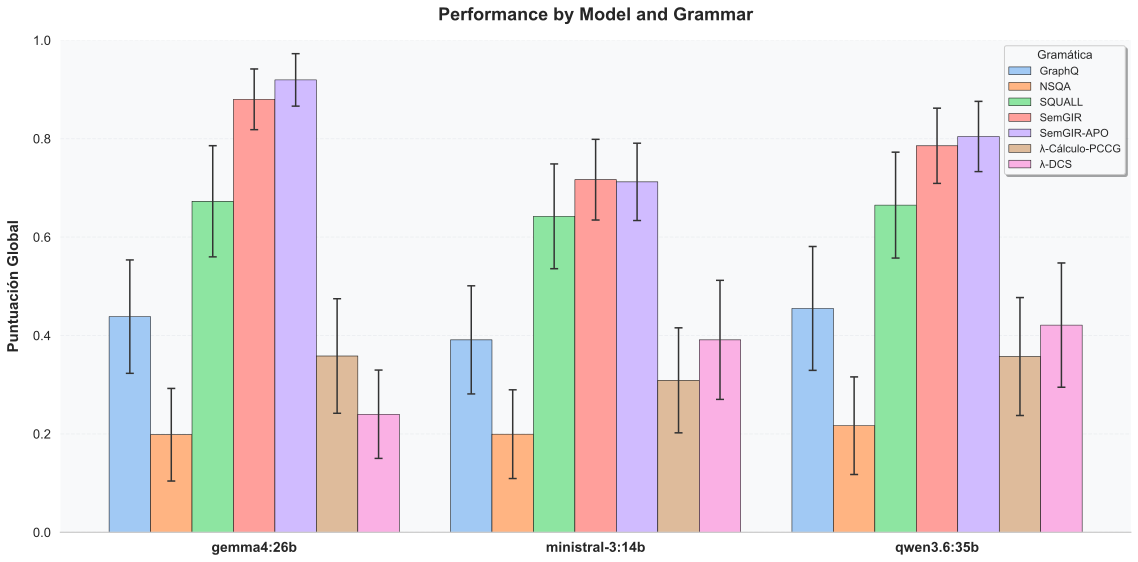

In [9]:
import numpy as np
from statistical_analysis_utils import compute_parametric_ci, plot_grouped_bars

models = query_medians['Model'].unique()
grammars = query_medians['Grammar'].unique()

means = {g: [] for g in grammars}
yerr_lower = {g: [] for g in grammars}
yerr_upper = {g: [] for g in grammars}

for m in models:
    m_data = query_medians[query_medians['Model'] == m]
    for g in grammars:
        g_data = m_data[m_data['Grammar'] == g]['Median_Overall_Score'].values
        if len(g_data) > 0:
            mean = np.mean(g_data)
            ci_low, ci_high = compute_parametric_ci(g_data)
            means[g].append(mean)
            yerr_lower[g].append(mean - ci_low)
            yerr_upper[g].append(ci_high - mean)
        else:
            means[g].append(0)
            yerr_lower[g].append(0)
            yerr_upper[g].append(0)

plot_grouped_bars(models, grammars, means, yerr_lower, yerr_upper, None, 
                  "Puntuación Global", 
                  "Performance by Model and Grammar")


## 3. Visualization: Performance by Grammar and Model (Means)

This graph is identical to the previous one, but instead of using the median, it uses the **mean of means** of each query. The error bars still represent the **95% Confidence Interval**.

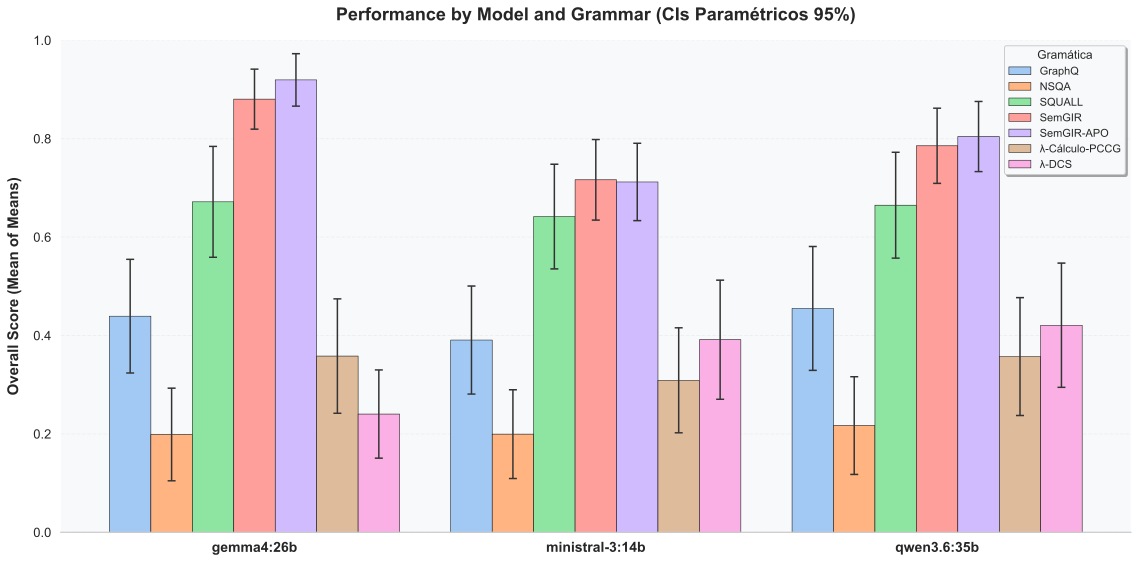

In [10]:
import numpy as np
from statistical_analysis_utils import compute_parametric_ci, plot_grouped_bars

models = query_means['Model'].unique()
grammars = query_means['Grammar'].unique()

means = {g: [] for g in grammars}
yerr_lower = {g: [] for g in grammars}
yerr_upper = {g: [] for g in grammars}

for m in models:
    m_data = query_means[query_means['Model'] == m]
    for g in grammars:
        g_data = m_data[m_data['Grammar'] == g]['Mean_Overall_Score'].values
        if len(g_data) > 0:
            mean = np.mean(g_data)
            ci_low, ci_high = compute_parametric_ci(g_data)
            means[g].append(mean)
            yerr_lower[g].append(mean - ci_low)
            yerr_upper[g].append(ci_high - mean)
        else:
            means[g].append(0)
            yerr_lower[g].append(0)
            yerr_upper[g].append(0)

plot_grouped_bars(models, grammars, means, yerr_lower, yerr_upper, None, 
                  "Overall Score (Mean of Means)", 
                  "Performance by Model and Grammar (CIs Paramétricos 95%)")


## 4. Paired Comparison of Top Languages (T-Test)

Below is a table for each model that pairwise compares the main languages (**SemGIR_APO**, **SemGIR** and **SQUALL**) using a **Paired T-Test (ttest_rel)** on the score of each query.
Statistically significant p-values (p < 0.05) are highlighted in **bold**.

Furthermore, **Cohen's d** is included to measure the effect size of the observed differences, with the following standard interpretation:
- $|d| < 0.2$: **Insignificant**
- $0.2 \leq |d| < 0.5$: **Small**
- $0.5 \leq |d| < 0.8$: **Moderate**
- $|d| \geq 0.8$: **Large**

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import itertools
from IPython.display import display, HTML
from statistical_analysis_utils import highlight_sig

# The 3 best languages (representations) to compare
grammars_to_compare = ['SemGIR-APO', 'SemGIR', 'SQUALL']
models_list = query_medians['Model'].unique()

# We automatically generate all possible pairs (3 elements -> 3 combinations)
pairs = list(itertools.combinations(grammars_to_compare, 2))

for m in models_list:
    print(f"\n{'='*50}")
    print(f"=== Language Comparison for: {m} ===")
    print(f"{'='*50}")
    
    data = {}
    for g in grammars_to_compare:
        g_data = query_medians[(query_medians['Model'] == m) & (query_medians['Grammar'] == g)].copy()
        # Collapse by Query ID to avoid duplicates due to the Thinking column
        g_agg = g_data.groupby('Query ID')['Median_Overall_Score'].mean()
        data[g] = g_agg
    
    comparisons = []
    
    for a, b in pairs:
        scores_a = data[a]
        scores_b = data[b]
        
        # We intersect the indices to align the queries
        common_queries = scores_a.index.intersection(scores_b.index)
        aligned_a = scores_a.loc[common_queries].values
        aligned_b = scores_b.loc[common_queries].values
        
        
        if len(aligned_a) > 1:
            diffs = aligned_a - aligned_b
            res = stats.ttest_rel(aligned_a, aligned_b)
            t_stat, p_val = float(res[0]), float(res[1])
            cohen_d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) != 0 else 0
            
            abs_d = abs(cohen_d)
            if abs_d < 0.2:
                interpretacion = 'Insignificante'
            elif abs_d < 0.5:
                interpretacion = 'Pequeño'
            elif abs_d < 0.8:
                interpretacion = 'Moderado'
            else:
                interpretacion = 'Grande'

            comparisons.append({
                'Comparación': f"{a} vs {b}",
                'Dif. Medias': diffs.mean(),
                't-statistic': t_stat,
                'p-value': p_val,
                "Cohen's d": cohen_d,
                'Interpretación': interpretacion,
                'Significativo (p<0.05)': 'S' if p_val < 0.05 else 'No'
            })
            
    df_comp = pd.DataFrame(comparisons)
    for col in ['Dif. Medias', 't-statistic', 'p-value', "Cohen's d"]:
        if col in df_comp:
            df_comp[col] = df_comp[col].astype(float).round(4)
            
    styled_df = df_comp.style.map(highlight_sig, subset=['p-value'])\
                             .apply(lambda x: ['font-weight: bold' if v == 'S' else '' for v in x], subset=['Significativo (p<0.05)'])
    display(styled_df)



=== Language Comparison for: gemma4:26b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,0.039400,1.198900,0.237000,0.178700,Insignificante,No
1,SemGIR-APO vs SQUALL,0.246700,4.626500,0.000000,0.689700,Moderado,S
2,SemGIR vs SQUALL,0.207200,3.787900,0.000500,0.564700,Moderado,S



=== Language Comparison for: ministral-3:14b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,-0.004400,-0.133700,0.894300,-0.019900,Insignificante,No
1,SemGIR-APO vs SQUALL,0.070000,1.200500,0.236400,0.179000,Insignificante,No
2,SemGIR vs SQUALL,0.074400,1.121600,0.268100,0.167200,Insignificante,No



=== Language Comparison for: qwen3.6:35b ===


,Comparación,Dif. Medias,t-statistic,p-value,Cohen's d,Interpretación,Significativo (p<0.05)
0,SemGIR-APO vs SemGIR,0.018900,0.503500,0.617100,0.075100,Insignificante,No
1,SemGIR-APO vs SQUALL,0.139400,2.215600,0.031900,0.330300,Pequeño,S
2,SemGIR vs SQUALL,0.120600,1.900000,0.064000,0.283200,Pequeño,No


## 5. Detailed Breakdown by Query (Gemma4:26b)

The following table presents one row per query, focusing on the **`gemma4:26b`** model and comparing the performance of **all grammars**.
For each cell, the **Mean of the runs** and its corresponding **Confidence Interval** are calculated.
The language with the highest score is shown in **bold**. If the difference between the best language and the others is **not statistically significant** (independent samples t-test, $p \ge 0.05$), they are also highlighted in bold to denote a statistical tie.

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, HTML
from statistical_analysis_utils import compute_margin

number_decimals = 2
percentage_decimals = 1

df_gemma = run_scores[run_scores['Model'] == 'gemma4:26b'].copy()

if 'Eval Score' not in df_gemma.columns and 'Run_Overall_Score' in df_gemma.columns:
    df_gemma.rename(columns={'Run_Overall_Score': 'Eval Score'}, inplace=True)
if 'Supported_Score' not in df_gemma.columns and 'Run_Supported_Score' in df_gemma.columns:
    df_gemma.rename(columns={'Run_Supported_Score': 'Supported_Score'}, inplace=True)

queries = sorted(df_gemma['Query ID'].unique())
grammars = df_gemma['Grammar'].unique()

results = []
for q in queries:
    q_data = df_gemma[df_gemma['Query ID'] == q]
    
    q_scores = {}
    q_means = {}
    q_margins = {}
    
    for g in grammars:
        g_subset = q_data[q_data['Grammar'] == g]
        scores = g_subset['Eval Score'].dropna().values
        supported = g_subset['Supported_Score'].dropna().values
        
        if len(supported) > 0 and len(scores) > 0:
            m, h = compute_margin(scores)
            q_scores[g] = scores
            q_means[g] = m
            q_margins[g] = h
        else:
            q_scores[g] = []
            q_means[g] = -1.0
            q_margins[g] = 0.0
            
    valid_gs = [g for g in grammars if q_means[g] >= 0]
    best_g = max(valid_gs, key=lambda g: q_means[g]) if valid_gs else None
    
    row_data = {'Query ID': q}
    for g in grammars:
        m = q_means[g]
        if m < 0:
            row_data[str(g)] = "-"
            continue
            
        h = q_margins[g]
        m_str = f"{m:.{number_decimals + 5}f}"
        m_trunc_str = m_str[:m_str.find('.') + number_decimals + 1]
        cell_str = f"{m_trunc_str} &plusmn; {h*100:.{percentage_decimals}f}%"
        
        is_bold = False
        if g == best_g:
            is_bold = True
        elif best_g is not None:
            scores_best = q_scores[best_g]
            scores_curr = q_scores[g]
            
            if np.isclose(m, q_means[best_g], atol=1e-7):
                is_bold = True
            elif len(scores_best) > 1 and len(scores_curr) > 1:
                res = stats.ttest_ind(scores_best, scores_curr, equal_var=False)
                p_val = float(res[1]) # type: ignore
                if (p_val == p_val) and p_val >= 0.05:
                    is_bold = True
                elif (p_val != p_val) and np.isclose(m, q_means[best_g]):
                    is_bold = True
            elif len(scores_curr) == 0:
                is_bold = False
            else:
                if np.isclose(m, q_means[best_g]):
                    is_bold = True
                    
        if is_bold:
            row_data[str(g)] = f"<b>{cell_str}</b>"
        else:
            row_data[str(g)] = cell_str
            
    results.append(row_data)

df_queries = pd.DataFrame(results)
display(HTML(df_queries.to_html(escape=False, index=False)))


Query ID,GraphQ,NSQA,SQUALL,SemGIR,SemGIR-APO,λ-Cálculo-PCCG,λ-DCS
Q01,0.85 ± 0.0%,1.00 ± 0.0%,0.98 ± 3.4%,1.00 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,0.50 ± 0.0%
Q02,-,-,0.99 ± 0.3%,1.00 ± 0.0%,1.00 ± 0.0%,0.99 ± 0.3%,0.24 ± 0.5%
Q03,0.20 ± 0.0%,-,0.95 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,-,-
Q04,-,-,-,1.00 ± 0.0%,1.00 ± 0.0%,-,-
Q05,-,-,0.30 ± 0.0%,0.30 ± 0.7%,0.39 ± 0.7%,-,-
Q06,0.60 ± 1.1%,0.20 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,0.50 ± 0.0%,-
Q07,0.75 ± 0.0%,0.40 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,0.95 ± 0.0%,0.22 ± 2.8%
Q08,1.00 ± 0.0%,0.59 ± 0.7%,1.00 ± 0.0%,1.00 ± 0.0%,1.00 ± 0.0%,0.20 ± 0.0%,0.40 ± 0.0%
Q09,0.50 ± 0.0%,-,-,0.50 ± 0.0%,1.00 ± 0.0%,-,0.09 ± 0.5%
Q10,-,-,-,0.51 ± 3.4%,1.00 ± 0.0%,-,-
